# IRIS - Connection I

![Concatenate Layer](https://github.com/DrKAI/image/blob/main/Concatenate%20Layer.png?raw=true)

In [2]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras

from sklearn.datasets import load_iris

## 데이터 불러오기

- iris.feature_names를 이용하여 판다스 데이터 프레임 만들기!

In [3]:
iris = load_iris()

x = iris.data
y = iris.target

In [4]:
df_x = pd.DataFrame(x, columns=iris.feature_names)
df_x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## train set, test set 구분하기

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
train_x, test_x, train_y, test_y = train_test_split(df_x, y, test_size=0.2, random_state=2021)

In [7]:
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

## **length끼리, width끼리**

In [8]:
print(df_x.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


In [9]:
tr_x_l = train_x.loc[:, ['sepal length (cm)', 'petal length (cm)'] ]
tr_x_w = train_x.loc[:, ['sepal width (cm)', 'petal width (cm)'] ]

In [10]:
tr_x_l.shape, tr_x_w.shape

((120, 2), (120, 2))

In [11]:
te_x_l = test_x.loc[:, ['sepal length (cm)', 'petal length (cm)'] ]
te_x_w = test_x.loc[:, ['sepal width (cm)', 'petal width (cm)'] ]

## One-hot Encoding

In [12]:
from tensorflow.keras.utils import to_categorical

In [13]:
train_y = to_categorical(train_y, 3)
test_y = to_categorical(test_y, 3)


In [14]:
train_y.shape

(120, 3)

## Modeling : multi-input & Concatenate layer

In [15]:
from tensorflow.keras.backend import clear_session
from tensorflow.keras.models import Model

from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.activations import relu, softmax

from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [16]:
# 1. 세션 클리어
clear_session()

# 2. 레이어 사슬처럼 엮기 : input 2개!
il_l = Input( shape=(2,) )
hl_l = Dense(2, activation=relu)(il_l)

il_w = Input( shape=(2,) )
hl_w = Dense(2, activation=relu)(il_w)

cl = Concatenate()([hl_l, hl_w])
ol = Dense(3, activation=softmax)(cl)

# 3. 모델 시작과 끝 지정
model = Model([il_l, il_w], ol)

# 4. 모델 컴파일
model.compile(loss=categorical_crossentropy, metrics=['accuracy'],
              optimizer=Adam())

## 모델 시각화

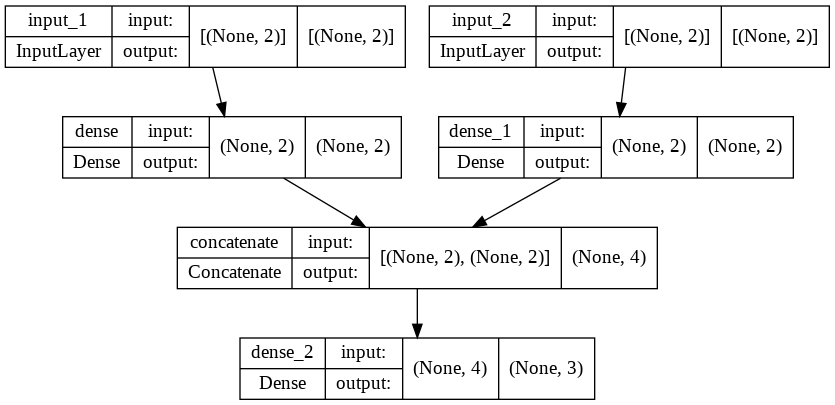

In [17]:
plot_model(model, show_shapes=True)

## 학습 시켜보기!

In [18]:
es = EarlyStopping(monitor='val_loss',
                   min_delta=0,
                   patience=30,
                   verbose=1,
                   restore_best_weights=True)

In [19]:
model.fit([tr_x_l, tr_x_w], train_y, validation_split=0.15,
          epochs=1000, verbose=1, callbacks=[es])

Epoch 1/1000
4/4 [==============================] - 3s 61ms/step - loss: 2.7362 - accuracy: 0.3333 - val_loss: 2.8932 - val_accuracy: 0.3333
Epoch 2/1000
4/4 [==============================] - 0s 13ms/step - loss: 2.6877 - accuracy: 0.3333 - val_loss: 2.8432 - val_accuracy: 0.3333
Epoch 3/1000
4/4 [==============================] - 0s 10ms/step - loss: 2.6399 - accuracy: 0.3333 - val_loss: 2.7950 - val_accuracy: 0.3333
Epoch 4/1000
4/4 [==============================] - 0s 14ms/step - loss: 2.5952 - accuracy: 0.3333 - val_loss: 2.7477 - val_accuracy: 0.3333
Epoch 5/1000
4/4 [==============================] - 0s 10ms/step - loss: 2.5501 - accuracy: 0.3333 - val_loss: 2.7020 - val_accuracy: 0.3333
Epoch 6/1000
4/4 [==============================] - 0s 16ms/step - loss: 2.5081 - accuracy: 0.3333 - val_loss: 2.6586 - val_accuracy: 0.3333
Epoch 7/1000
4/4 [==============================] - 0s 11ms/step - loss: 2.4662 - accuracy: 0.3333 - val_loss: 2.6173 - val_accuracy: 0.3333
Epoch 8/1000


---
---
---
---
---

# IRIS - Connection I practice

- 위의 코드를 **그대로** 따라서 코드 작성하기!

## 데이터 불러오기

- iris.feature_names를 이용하여 판다스 데이터 프레임 만들기!

In [20]:
iris = load_iris()

x = iris.data
y = iris.target

In [21]:
df_x = pd.DataFrame(x, columns=iris.feature_names)
df_x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## train set, test set 구분하기

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2022)

## **length끼리, width끼리**

In [24]:
tr_x_l = train_x.loc[:, ['sepal length (cm)', 'petal length (cm)'] ]
tr_x_w = train_x.loc[:, ['sepal width (cm)', 'petal width (cm)'] ]

In [25]:
te_x_l = test_x.loc[:, ['sepal length (cm)', 'petal length (cm)'] ]
te_x_w = test_x.loc[:, ['sepal width (cm)', 'petal width (cm)'] ]

## One-hot Encoding

In [26]:
from tensorflow.keras.utils import to_categorical

In [27]:
y_train=to_categorical(y_train,3)
y_test=to_categorical(y_test,3)

## Modeling : multi-input & Concatenate layer

In [28]:
x_train.shape

(120, 4)

In [54]:

keras.backend.clear_session()
il_l=keras.layers.Input(shape=(2,))
hl_l=keras.layers.Dense(2,activation='swish')(il_l)

il_w=keras.layers.Input(shape=(2,))
hl_w=keras.layers.Dense(2,activation='swish')(il_w)

co=keras.layers.Concatenate()([hl_l,hl_w])
ol=keras.layers.Dense(3,activation='softmax')(co)

model=keras.models.Model([il_l,il_w],ol)
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['accuracy'])

In [55]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 2)]          0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 2)]          0           []                               
                                                                                                  
 dense (Dense)                  (None, 2)            6           ['input_1[0][0]']                
                                                                                                  
 dense_1 (Dense)                (None, 2)            6           ['input_2[0][0]']                
                                                                                              

## 모델 시각화

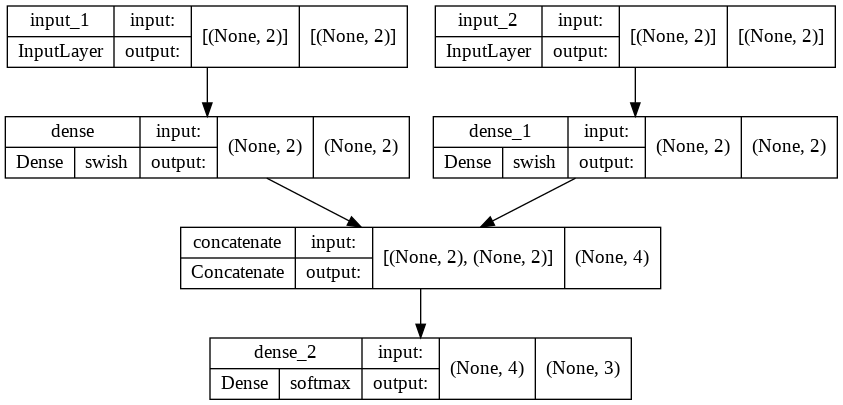

In [57]:
plot_model(model,show_shapes=True,show_layer_activations=True)

## 학습 시켜보기!

In [60]:
es = EarlyStopping(monitor='val_loss',
                   min_delta=0,
                   patience=1,
                   verbose=1,
                   restore_best_weights=True)

In [61]:
model.fit([tr_x_l, tr_x_w], y_train, validation_split=0.1, epochs=1000, verbose=1, callbacks=[es])

Epoch 1/1000
4/4 [==============================] - 0s 22ms/step - loss: 1.1395 - accuracy: 0.3519 - val_loss: 0.9913 - val_accuracy: 0.4167
Epoch 2/1000
4/4 [==============================] - 0s 11ms/step - loss: 1.1340 - accuracy: 0.3519 - val_loss: 0.9950 - val_accuracy: 0.4167
Epoch 2: early stopping
